<a href="https://colab.research.google.com/github/Carereen/image-processing/blob/main/Lab4_Sec2_6853800122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# drive.mount('/content/drive/My Drive/2568-term2/image/week4/')

Mounted at /content/drive


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
from numpy import sqrt
import sys
from math import exp, sqrt

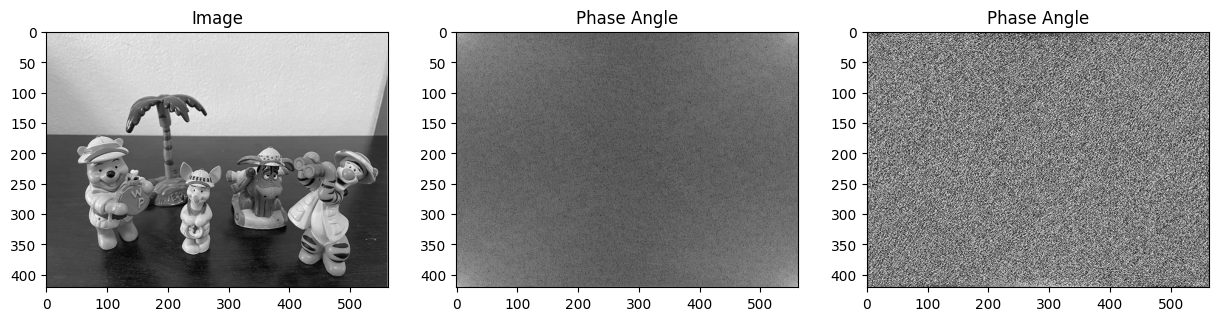

In [ ]:
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize = (15, 10), constrained_layout = False)

plt.subplot(131), plt.imshow(image_gray, "gray"), plt.title("Image")

# np.fft.fft2()
original = np.fft.fft2(image_gray)

# np.log() is a spectrum
plt.subplot(132), plt.imshow(np.log(np.abs(original)), "gray"), plt.title("Phase Angle")

# np.angle() is Phase Angle.
plt.subplot(133), plt.imshow(np.angle(original), "gray"), plt.title("Phase Angle")
plt.show()

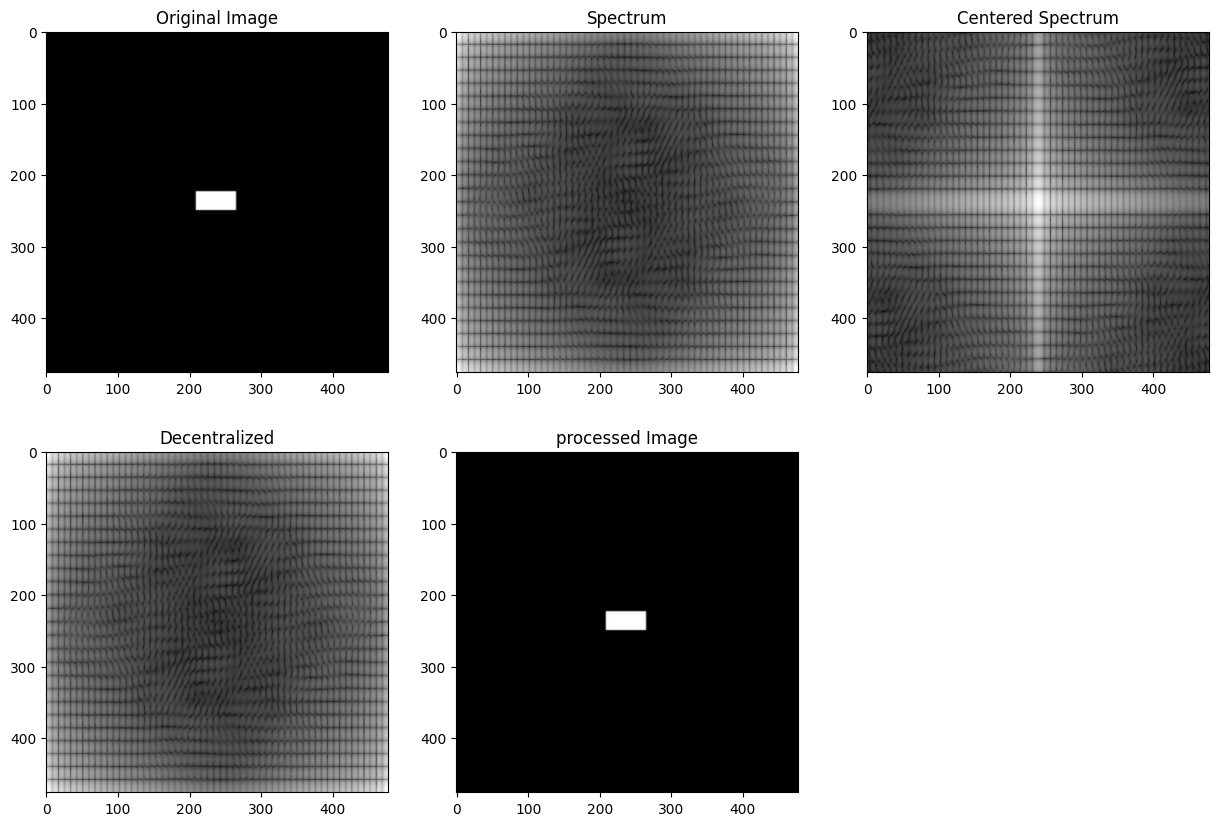

In [ ]:
# fast fourier transformation
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img1.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize = (15, 10), constrained_layout = False)

plt.subplot(231), plt.imshow(image_gray, "gray"), plt.title("Original Image")

original = np.fft.fft2(image_gray)
plt.subplot(232), plt.imshow(np.log(1 + np.abs(original)), "gray"), plt.title("Spectrum")

center = np.fft.fftshift(original)
plt.subplot(233), plt.imshow(np.log(1 + np.abs(center)), "gray"), plt.title("Centered Spectrum")

#Inverse FFT (no modification)
inv_center = np.fft.ifftshift(center)
plt.subplot(234), plt.imshow(np.log(1 + np.abs(inv_center)), "gray"), plt.title("Decentralized")

processed_img = np.fft.ifft2(inv_center)
plt.subplot(235), plt.imshow(np.abs(processed_img), "gray"), plt.title("processed Image")

plt.show()

In [ ]:
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)

# Low pass Filter
def idealFilterLP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      if distance((y, x), center) < D0:
        base[y, x] = 1
  return base

# High Pass
def idealFilterHP(D0, imgShape):
  base = np.ones(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      if distance((y, x), center) < D0:
        base[y, x] = 0

  return base

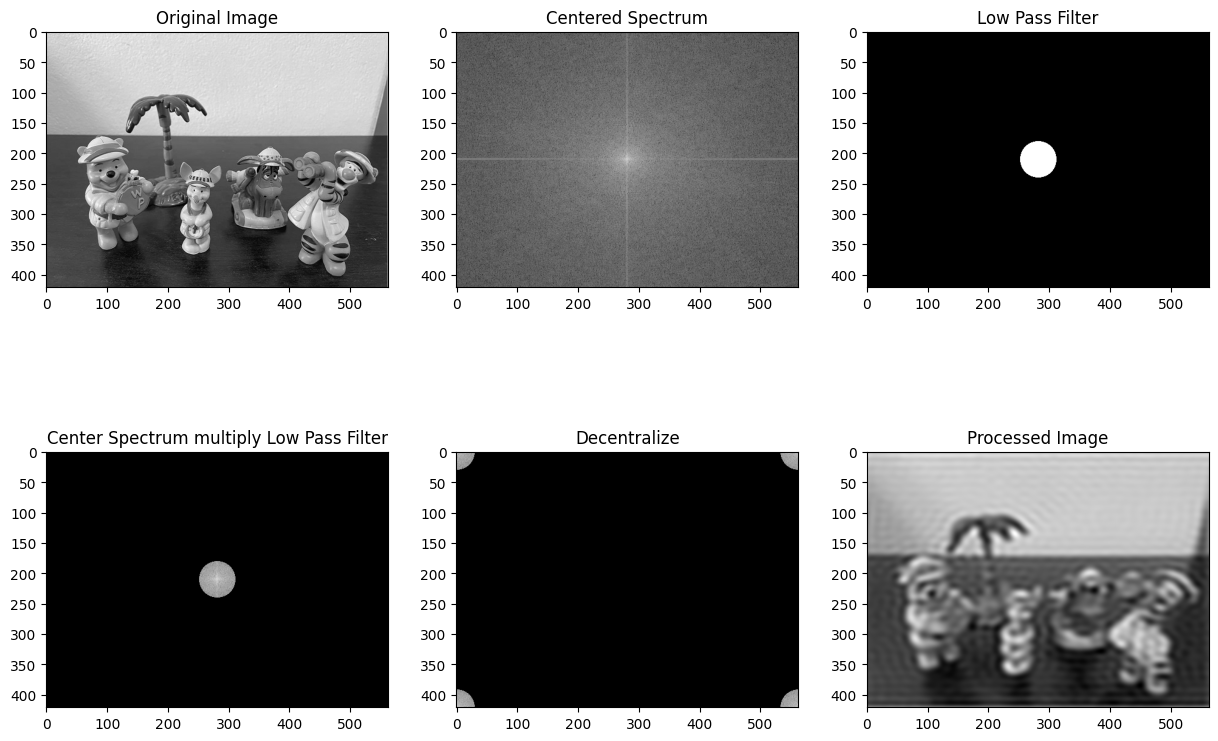

In [ ]:
# Low Pass
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
filter_size = 30

plt.figure(figsize = (15, 10), constrained_layout = False)

plt.subplot(231), plt.imshow(image_gray, "gray"), plt.title("Original Image")
original = np.fft.fft2(image_gray)

center = np.fft.fftshift(original)
plt.subplot(232), plt.imshow(np.log(1 + np.abs(center)), "gray"), plt.title("Centered Spectrum")

LowPass = idealFilterLP(filter_size, image_gray.shape)
plt.subplot(233), plt.imshow(np.abs(LowPass), "gray"), plt.title("Low Pass Filter")

LowPassCenter = center * idealFilterLP(filter_size, image_gray.shape)
plt.subplot(234), plt.imshow(np.log(1 + np.abs(LowPassCenter)), "gray"),
plt.title("Center Spectrum multiply Low Pass Filter")

LowPass = np.fft.ifftshift(LowPassCenter)
plt.subplot(235), plt.imshow(np.log(1 + np.abs(LowPass)), "gray"), plt.title("Decentralize")

inverse_LowPass = np.fft.ifft2(LowPass)
plt.subplot(236), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Processed Image")

plt.show()

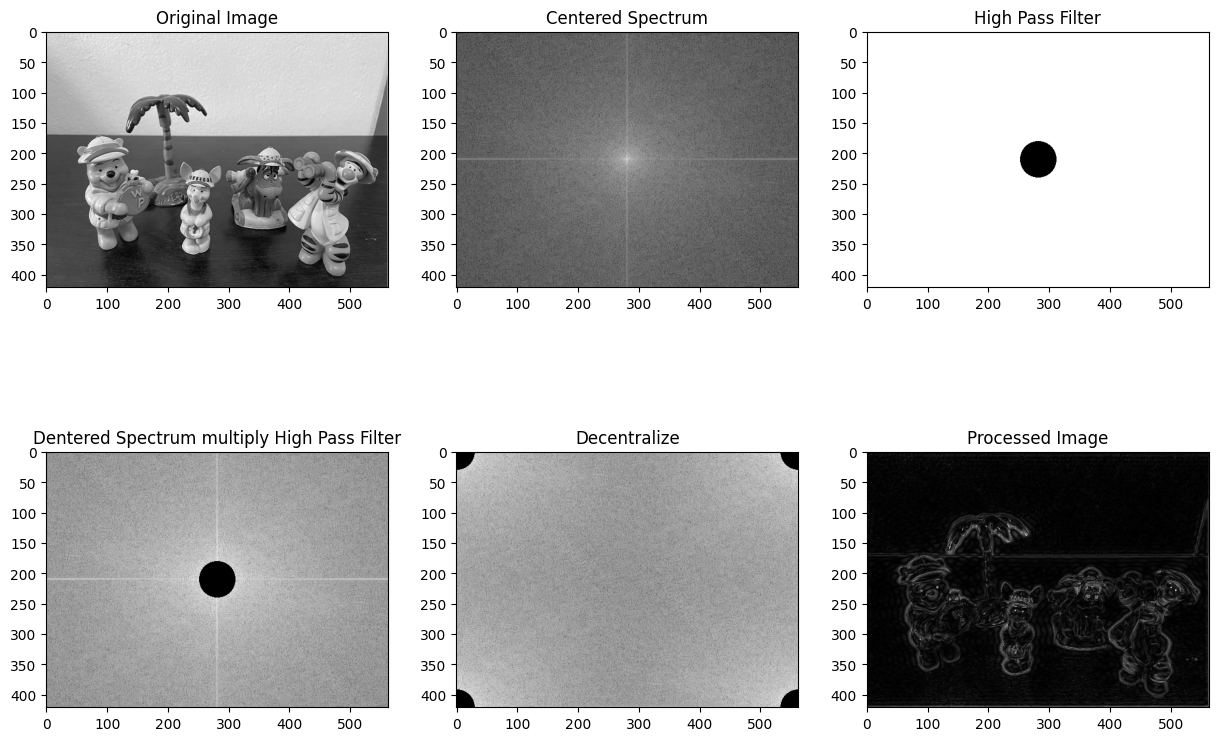

In [ ]:
# Higt Pass
plt.figure(figsize = (15, 10), constrained_layout = False)
filter_size = 30

plt.subplot(231), plt.imshow(image_gray, "gray"), plt.title("Original Image")
plt.subplot(232), plt.imshow(np.log(1 + np.abs(center)), "gray"), plt.title("Centered Spectrum")

HighPass = idealFilterHP(filter_size, image_gray.shape)
plt.subplot(233), plt.imshow(np.abs(HighPass), "gray"), plt.title("High Pass Filter")

HighPassCenter = center * idealFilterHP(filter_size, image_gray.shape)
plt.subplot(234), plt.imshow(np.log(1 + np.abs(HighPassCenter)), "gray"),
plt.title("Dentered Spectrum multiply High Pass Filter")

HighPass = np.fft.ifftshift(HighPassCenter)
plt.subplot(235), plt.imshow(np.log(1 + np.abs(HighPass)), "gray"), plt.title("Decentralize")

inverse_HighPass = np.fft.ifft2(HighPass)
plt.subplot(236), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Processed Image")

plt.show()

In [ ]:
# Butterworth Filter
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)

def butterworthLP(D0, imgShape, n):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 / (1 + (distance((y, x), center)/ D0) ** (2 * n))
  return base

def butterworthHP(D0, imgShape, n):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = [rows / 2, cols / 2]
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 - 1 / (1 + (distance((y, x), center) / D0) ** (2 * n))
  return base

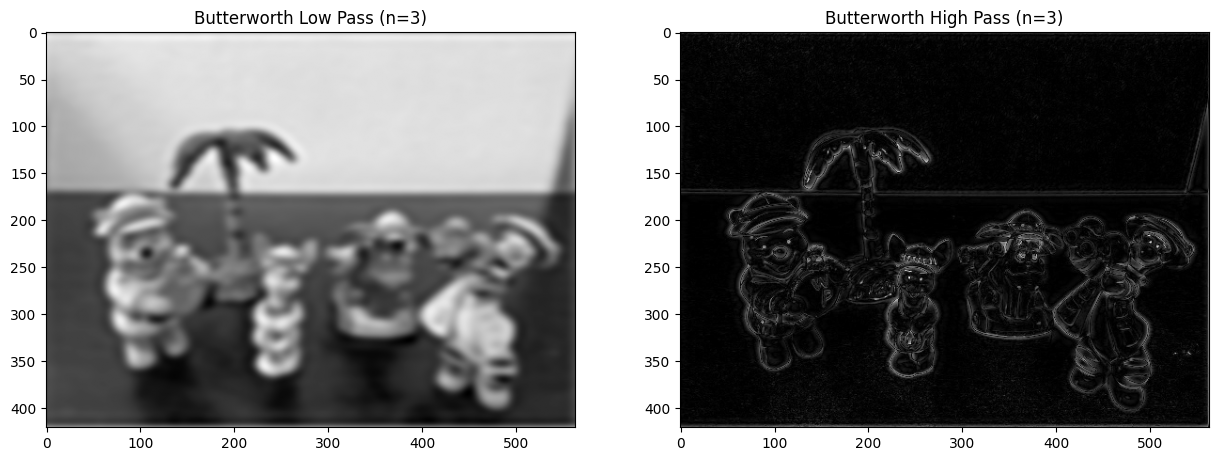

In [ ]:
# n = 3
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
D0 = 30
n = 3

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

plt.figure(figsize = (15, 10), constrained_layout = False)

LowPassCenter = center * butterworthLP(D0, image_gray.shape, n)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)

plt.subplot(121), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (n=" +str(n)+")")

HighPassCenter = center * butterworthHP(D0, image_gray.shape, n)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)

plt.subplot(122), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (n=" +str(n)+")")
plt.show()

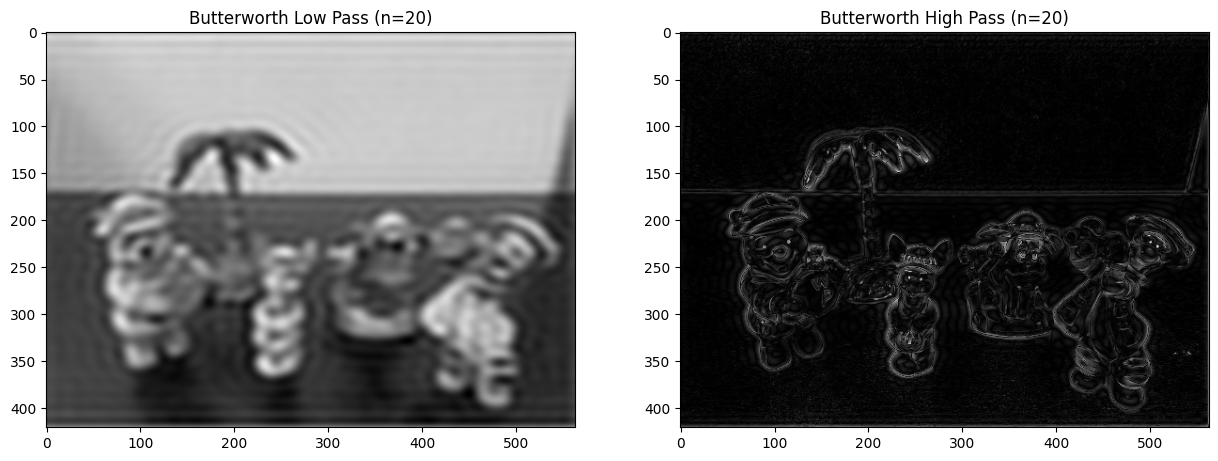

In [ ]:
# n = 20
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
D0 = 30
n = 20

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

plt.figure(figsize = (15, 10), constrained_layout = False)

LowPassCenter = center * butterworthLP(D0, image_gray.shape, n)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)

plt.subplot(121), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (n=" +str(n)+")")

HighPassCenter = center * butterworthHP(D0, image_gray.shape, n)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_HighPass = np.fft.ifft2(HighPass)

plt.subplot(122), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (n=" +str(n)+")")
plt.show()

In [ ]:
# Gaussian Filter
def distance(point1, point2):
  return sqrt((point1[0] - point2[0]) ** 2 + (point1[0] - point2[1]) ** 2)

def gaussianLP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = exp(((-distance((y, x), center) ** 2) / (2 * (D0 ** 2))))
  return base

def gaussianHP(D0, imgShape):
  base = np.zeros(imgShape[:2])
  rows, cols = imgShape[:2]
  center = (rows / 2, cols / 2)
  for x in range(cols):
    for y in range(rows):
      base[y, x] = 1 - exp(((-distance((y, x), center) ** 2) / (2 * (D0 ** 2))))
  return base

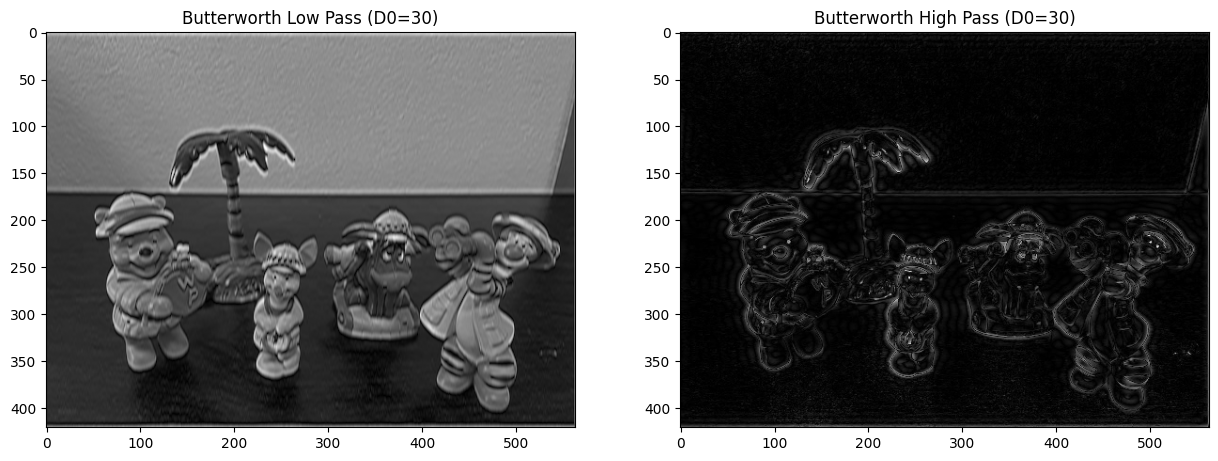

In [ ]:
# D = 30
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

D0 = 30

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

plt.figure(figsize = (15, 10), constrained_layout = False)

LowPassCenter = center * gaussianLP(D0, image_gray.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)

plt.subplot(121), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (D0="+ str(D0)+ ")")

HighPassCenter = center * gaussianHP(D0, image_gray.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_highPass = np.fft.ifft2(HighPass)

plt.subplot(122), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (D0=" + str(D0)+")")
plt.show()

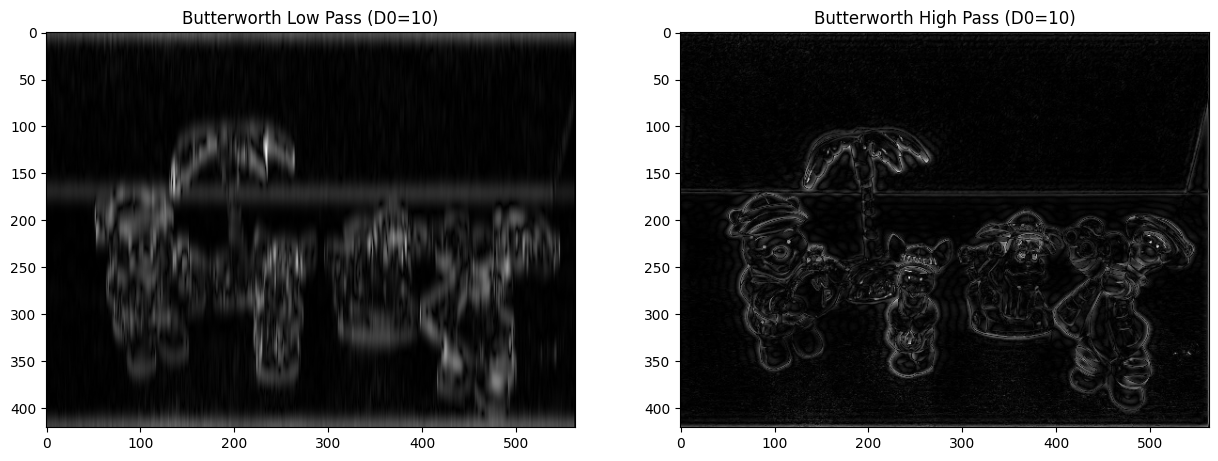

In [ ]:
# D = 10
path = '/content/drive/My Drive/2568-term2/image/week4/'
image_name = 'img2.jpg'
image_bgr = cv2.imread(path + image_name)

if image_bgr is None:
  print(f"Image file not found. Please check the path:{path + image_name} .")
  sys.exit()

image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

D0 = 10

original = np.fft.fft2(image_gray)
center = np.fft.fftshift(original)

plt.figure(figsize = (15, 10), constrained_layout = False)

LowPassCenter = center * gaussianLP(D0, image_gray.shape)
LowPass = np.fft.ifftshift(LowPassCenter)
inverse_LowPass = np.fft.ifft2(LowPass)

plt.subplot(121), plt.imshow(np.abs(inverse_LowPass), "gray"), plt.title("Butterworth Low Pass (D0="+ str(D0)+ ")")

HighPassCenter = center * gaussianHP(D0, image_gray.shape)
HighPass = np.fft.ifftshift(HighPassCenter)
inverse_highPass = np.fft.ifft2(HighPass)

plt.subplot(122), plt.imshow(np.abs(inverse_HighPass), "gray"), plt.title("Butterworth High Pass (D0=" + str(D0)+")")
plt.show()

# Task 5
Gaussian เป็นตัวกรองที่เหมาะสมที่สุดเพราะได้ภาพที่สวยและนุ่มที่สุดเหมาะกับการเอาไปทำงานจริง ส่วน ideal ภาพคมแต่จะเกิดเป็นคลื่น, butterworth ความคมชัดและความนุ่มจะอยู่ระดับกลางไม่โดนเด่นไปในทางใดเหมาะาำหรับใช้งานทั่วไป
